<a href="https://colab.research.google.com/github/AbiramiSS-2004/stroke-risk-ml-replication/blob/main/Stroke_Risk_Replication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stroke Risk ML Replication
# Stroke Risk ML Replication

This notebook replicates a machine learning–based stroke risk prediction study
using a public Kaggle dataset. The aim is reproducibility and baseline validation.

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib lifelines kaggle
!pip -q install xgboost catboost

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00


In [2]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n\t"username": "Abirami Nayagam",\r\n\t"key": "KGAT_3db27b58e1b14bbca26d8cb2840f2365"\r\n}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d fedesoriano/stroke-prediction-dataset -p data
!unzip -o data/stroke-prediction-dataset.zip -d data
!ls data

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
License(s): copyright-authors
  0% 0.00/67.4k [00:00<?, ?B/s]
100% 67.4k/67.4k [00:00<00:00, 292MB/s]
Archive:  data/stroke-prediction-dataset.zip
  inflating: data/healthcare-dataset-stroke-data.csv  
healthcare-dataset-stroke-data.csv  stroke-prediction-dataset.zip


In [5]:
import pandas as pd

csv_path = "data/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
import pandas as pd

df = pd.read_csv("data/healthcare-dataset-stroke-data.csv")
print(df.shape)
df.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [8]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [9]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [10]:
df = df.drop(columns=["id"])

In [11]:
X = df.drop(columns=["stroke"])
y = df["stroke"].astype(int)

In [12]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

numeric_cols, categorical_cols

(Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object'),
 Index(['gender', 'ever_married', 'work_type', 'Residence_type',
        'smoking_status'],
       dtype='object'))

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [14]:
y.value_counts(normalize=True)

,proportion
stroke,
0,0.951272
1,0.048728


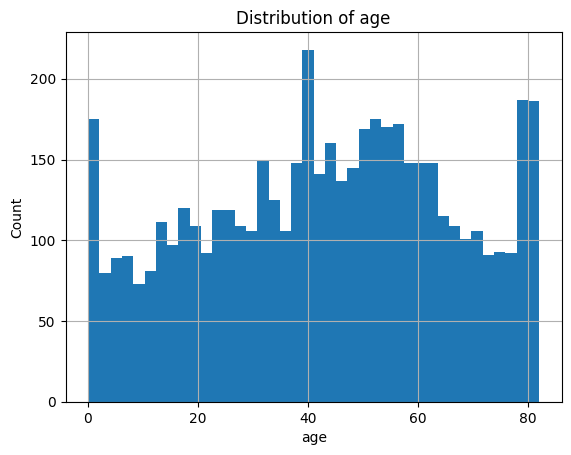

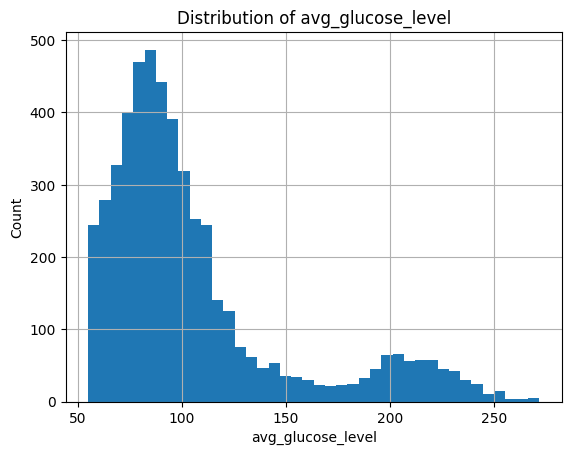

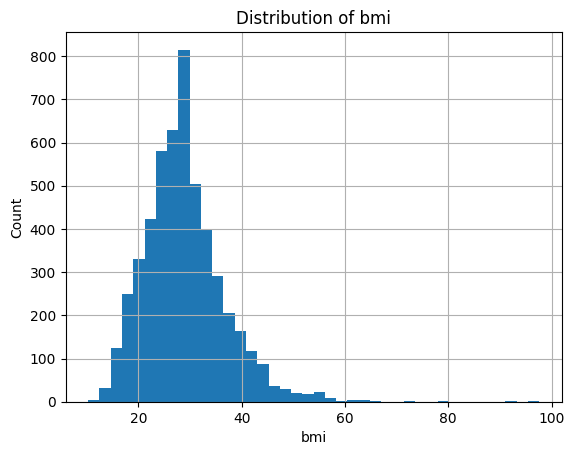

In [15]:
import matplotlib.pyplot as plt

for col in ["age", "avg_glucose_level", "bmi"]:
    plt.figure()
    df[col].hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

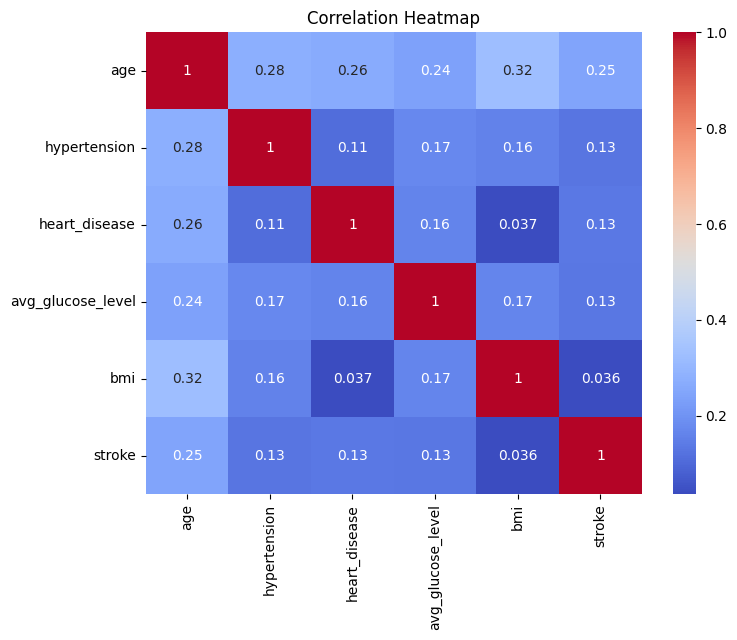

In [16]:
import seaborn as sns

corr = df[numeric_cols.tolist() + ["stroke"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [19]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        use_label_encoder=False
    ),
    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42
    )
}

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUROC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:59:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1,AUROC
0,Decision Tree,0.908676,0.157895,0.200000,0.176471,0.572565
1,KNN,0.947815,0.000000,0.000000,0.000000,0.629410
2,Naive Bayes,0.311807,0.065603,0.986667,0.123026,0.769218
3,Gradient Boosting,0.949119,0.285714,0.026667,0.048780,0.831605
4,AdaBoost,0.951076,0.000000,0.000000,0.000000,0.824490
5,XGBoost,0.940639,0.192308,0.066667,0.099010,0.792693
6,CatBoost,0.947815,0.222222,0.026667,0.047619,0.814056


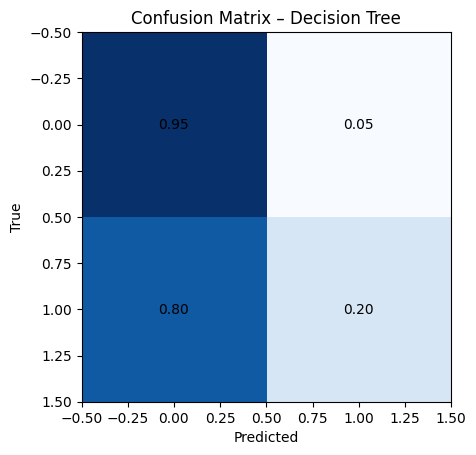

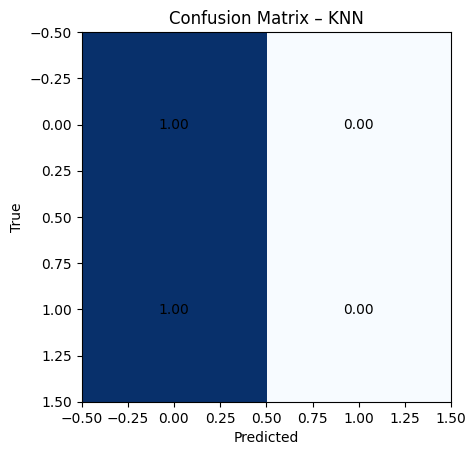

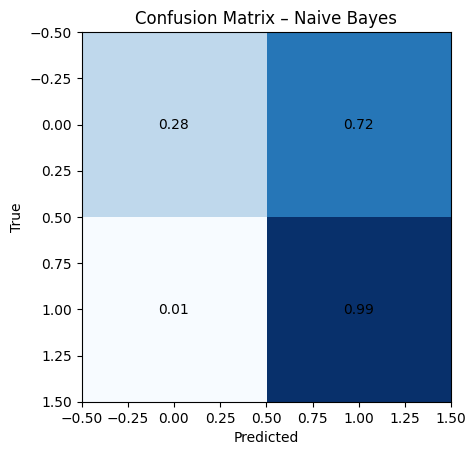

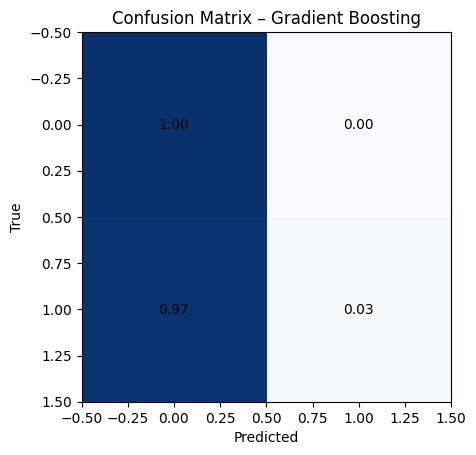

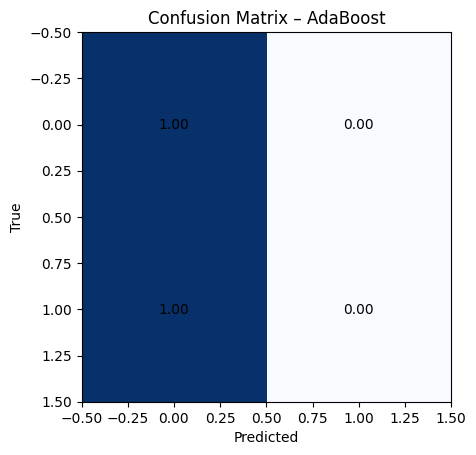

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:00:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


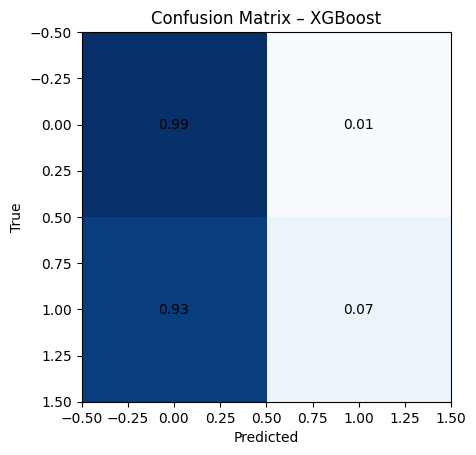

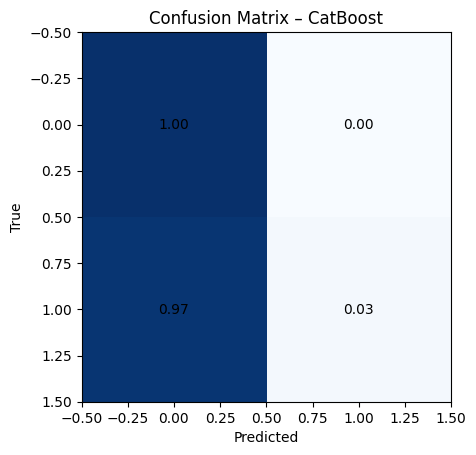

In [21]:
from sklearn.metrics import confusion_matrix
import numpy as np

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, normalize="true")

    plt.figure()
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center")

    plt.show()

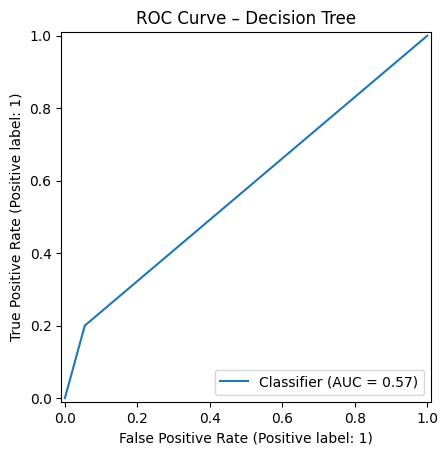

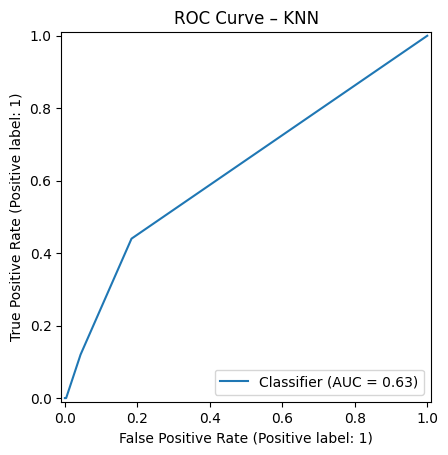

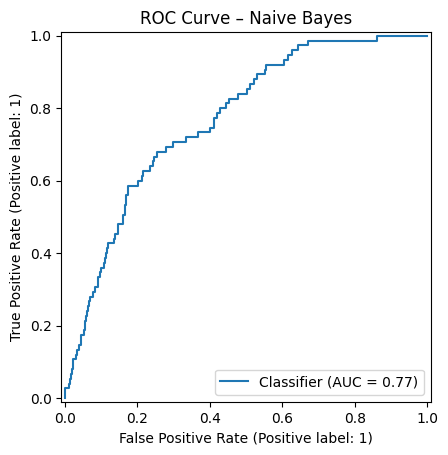

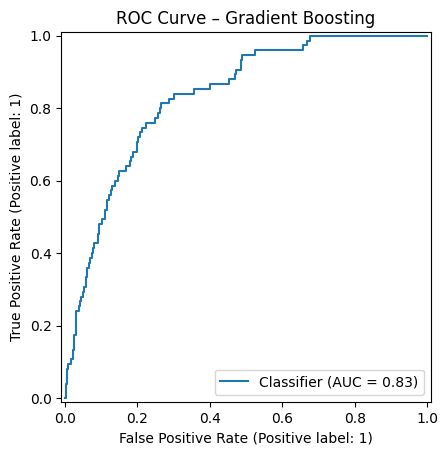

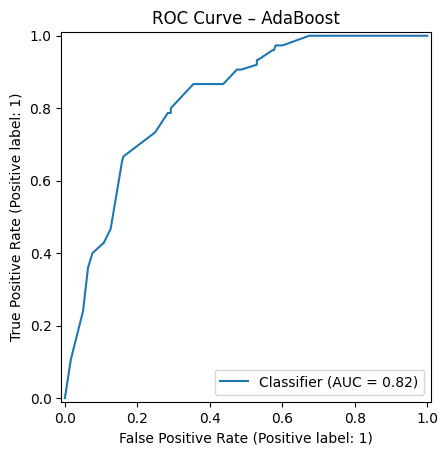

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:00:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


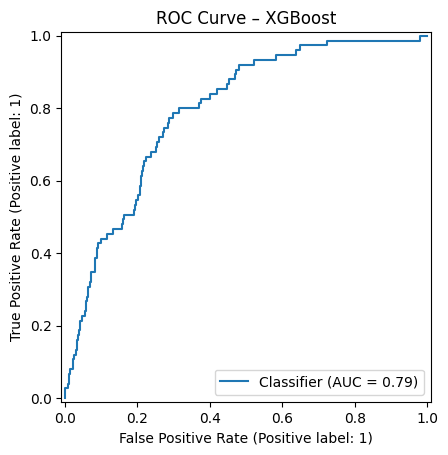

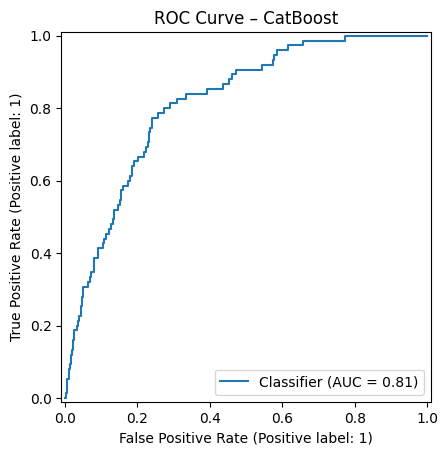

In [22]:
from sklearn.metrics import RocCurveDisplay

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:,1]

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"ROC Curve – {name}")
    plt.show()

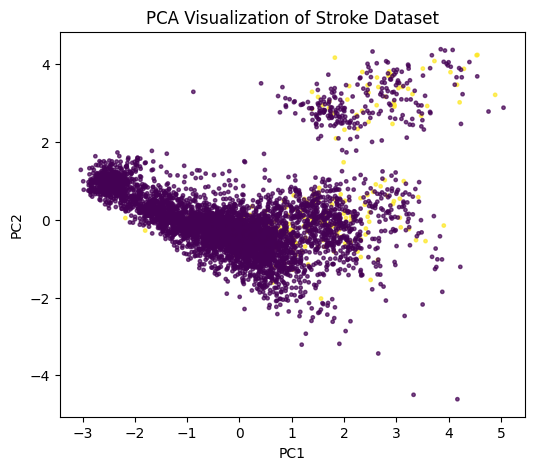

In [24]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

X_processed = preprocessor.fit_transform(X)

# Safely convert to dense if needed
if hasattr(X_processed, "toarray"):
    X_dense = X_processed.toarray()
else:
    X_dense = X_processed

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=6, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Stroke Dataset")
plt.show()

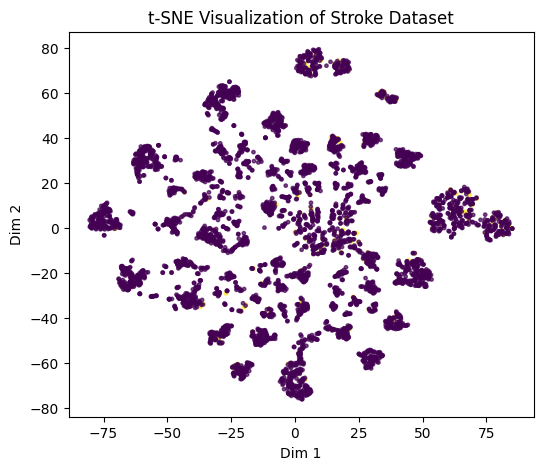

In [25]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_dense)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, s=6, alpha=0.7)
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("t-SNE Visualization of Stroke Dataset")
plt.show()

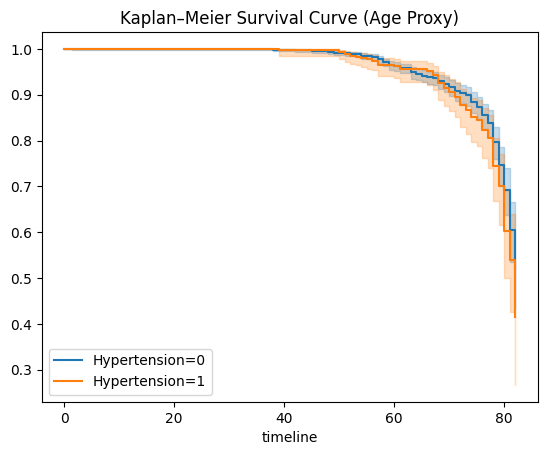

In [26]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

plt.figure()
for grp, sub in df.groupby("hypertension"):
    kmf.fit(sub["age"], sub["stroke"], label=f"Hypertension={grp}")
    kmf.plot_survival_function()

plt.title("Kaplan–Meier Survival Curve (Age Proxy)")
plt.show()

In [27]:
from lifelines import CoxPHFitter

cox_df = df[["age", "stroke", "hypertension", "heart_disease", "avg_glucose_level", "bmi"]]
cox_df.columns = ["duration", "event", "hypertension", "heart_disease", "avg_glucose_level", "bmi"]

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="duration", event_col="event")
cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
hypertension,0.141567,1.152078,0.145500,-0.143607,0.426741,0.866228,1.532256,0.0,0.972973,0.330567,1.596987
heart_disease,-0.010330,0.989723,0.164480,-0.332705,0.312045,0.716982,1.366216,0.0,-0.062805,0.949922,0.074119
avg_glucose_level,0.002418,1.002421,0.001056,0.000348,0.004487,1.000348,1.004497,0.0,2.289422,0.022055,5.502759
bmi,0.024849,1.025161,0.010881,0.003523,0.046176,1.003529,1.047259,0.0,2.283713,0.022388,5.481104
